In [287]:
# import libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# connect to db
connection = sqlite3.connect("fracfocus.db")

# create cursor object
cursor = connection.cursor()

In [288]:
# select all disclosures, grouped by State to see which state has the most hydraulic fracturing 
statement = '''
    SELECT StateName, Latitude, Longitude, COUNT(*) as num_disclosures
    FROM disclosures
    WHERE Latitude IS NOT NULL
    AND Longitude IS NOT NULL
    GROUP BY StateName
    ORDER BY num_disclosures DESC;
'''
disclosures_by_state_df = pd.read_sql_query(statement, connection)


In [289]:
print('query 1 data')
disclosures_by_state_df

query 1 data


,StateName,Latitude,Longitude,num_disclosures
0,Texas,32.283431,-101.906575,120064
1,Colorado,39.478411,-108.201450,21841
2,Oklahoma,35.841820,-99.749090,20165
3,North Dakota,47.733591,-102.471791,18310
4,New Mexico,32.274910,-103.507960,16610
5,Pennsylvania,39.893301,-80.296207,11633
6,Wyoming,42.972810,-105.953840,6883
7,Utah,39.997503,-109.474500,6210
8,Louisiana,32.163293,-93.475972,4867
9,California,35.483473,-119.755625,3825


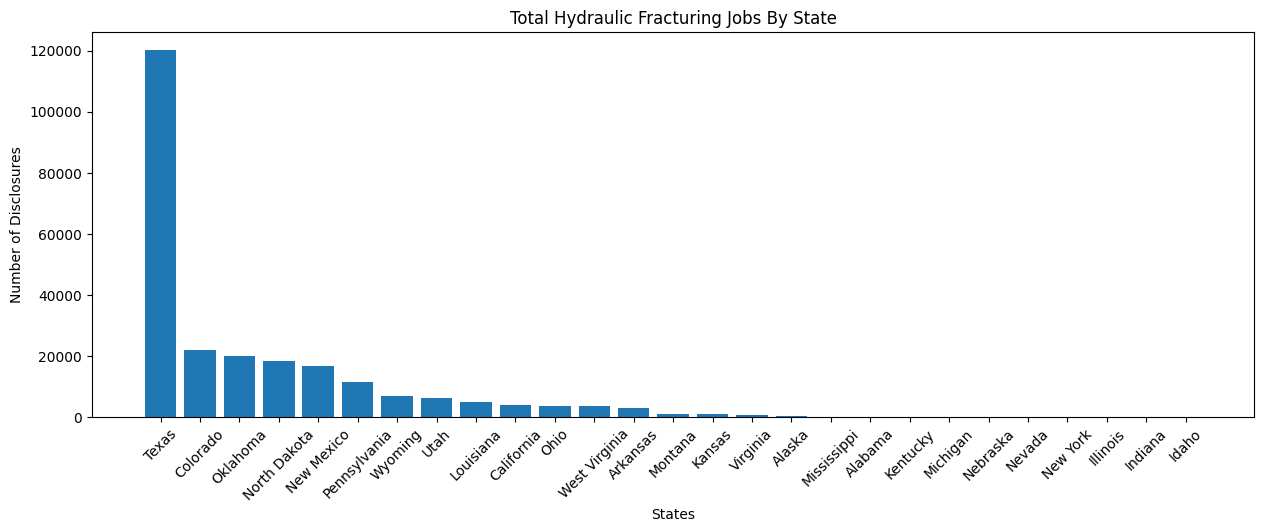

In [290]:
# graph in bar chart
plt.figure(figsize=(15,5))

plt.bar(disclosures_by_state_df['StateName'], disclosures_by_state_df['num_disclosures'])

plt.xticks(rotation=45)
plt.xlabel('States')
plt.ylabel('Number of Disclosures')
plt.title('Total Hydraulic Fracturing Jobs By State')

plt.show()

In [291]:
#most common chemicals used
# 56 381 of them are actually NULL
statement = '''
    SELECT IngredientName, COUNT(*) as num_disclosures
    FROM registry
    WHERE IngredientName is NOT NULL
    GROUP BY IngredientName
    ORDER BY num_disclosures DESC
    LIMIT 30;
'''
common_chemicals_df = pd.read_sql_query(statement, connection)
common_chemicals_df

,IngredientName,num_disclosures
0,Water,32513
1,Methanol,12308
2,Ethylene Glycol,6407
3,"Crystalline silica, quartz",5060
4,Proprietary,4649
5,Hydrochloric Acid,4470
6,Isopropanol,4333
7,Sodium chloride,4212
8,Ethanol,4004
9,Sodium Chloride,3524


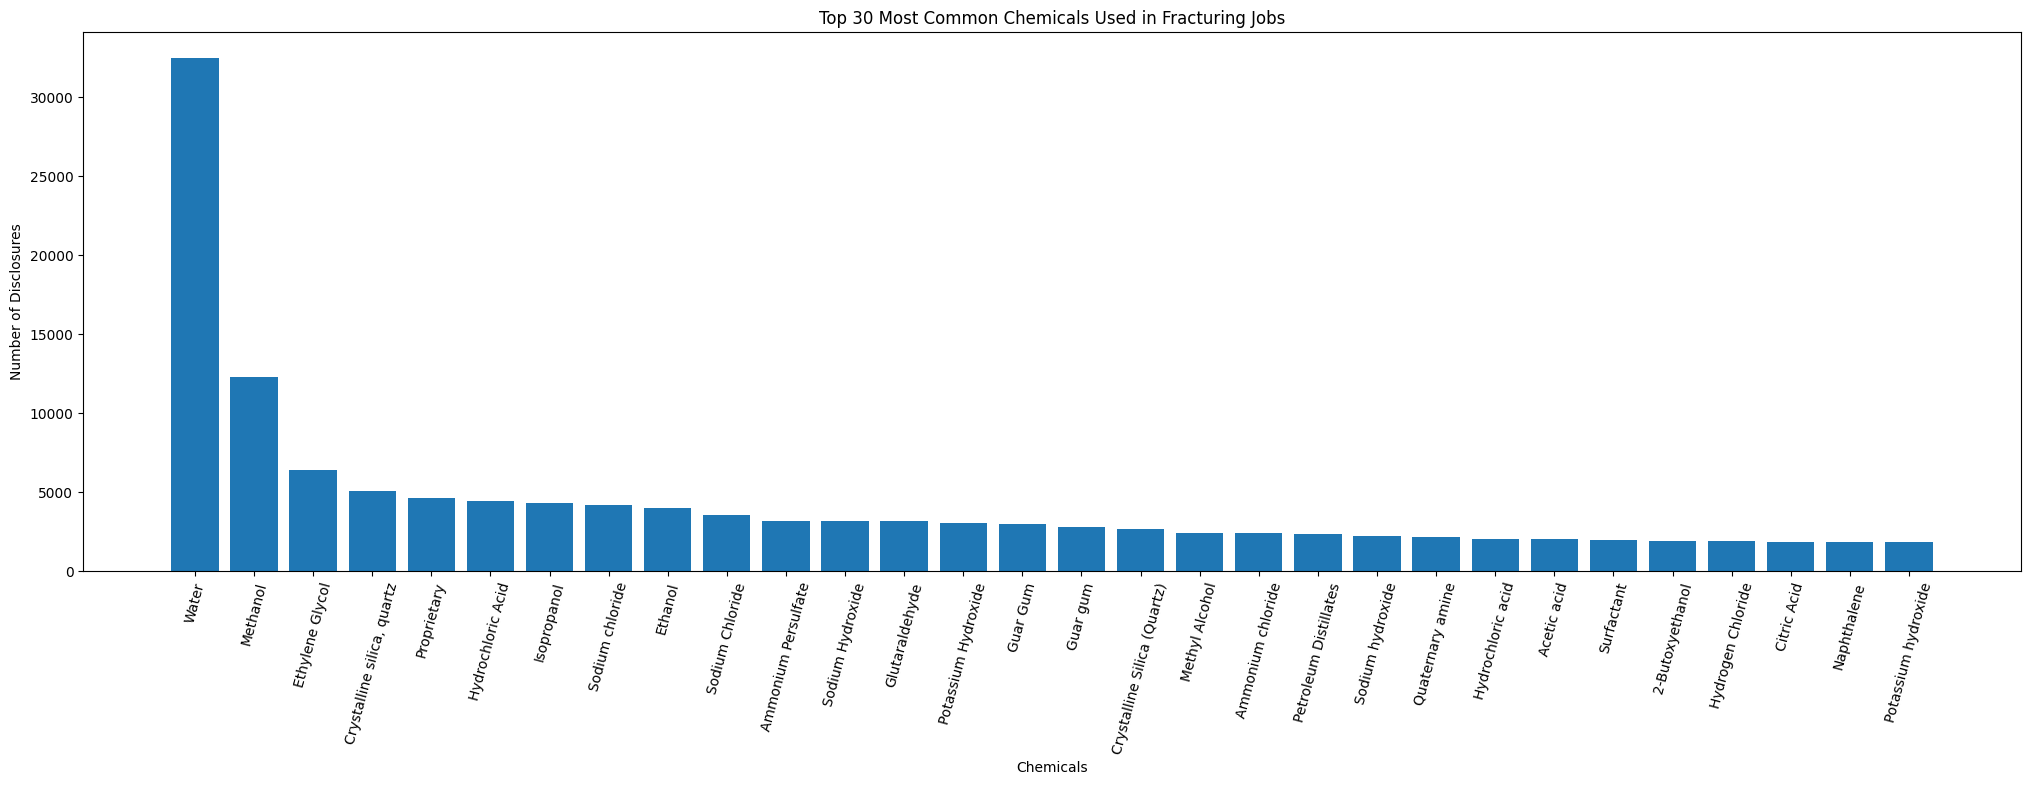

In [292]:
# graph in bar chart
plt.figure(figsize=(25,7))

plt.bar(common_chemicals_df['IngredientName'], common_chemicals_df['num_disclosures'])

plt.xticks(rotation=75)
plt.xlabel('Chemicals')
plt.ylabel('Number of Disclosures')
plt.title('Top 30 Most Common Chemicals Used in Fracturing Jobs')

plt.show()

In [293]:
# Water Use By Operator (with more than 10 Wells)
statement = '''
    SELECT OperatorName, strftime('%Y', JobStartDate) AS year, COUNT(*) as num_disclosures, SUM(TotalBaseWaterVolume) AS total_water_consump
    FROM disclosures
    WHERE TotalBaseWaterVolume is NOT NULL
    GROUP BY OperatorName
    HAVING num_disclosures > 10
    ORDER BY total_water_consump DESC;
'''
water_consump_by_operator_df = pd.read_sql_query(statement, connection)
water_consump_by_operator_df

,OperatorName,year,num_disclosures,total_water_consump
0,"EOG Resources, Inc.",2011,9220,1.125251e+11
1,Pioneer Natural Resources,2011,6116,9.293765e+10
2,XTO Energy/ExxonMobil,2011,7213,8.460863e+10
3,Diamondback E&P LLC,2011,2953,5.905654e+10
4,Devon Energy Production Company L. P.,2010,5652,5.164449e+10
...,...,...,...,...
879,"WCT Operating, LLC",2014,24,1.754370e+05
880,Johnson & Ernst Operating Co.,2012,22,1.636680e+05
881,Little Thunder,2018,19,1.563380e+05
882,"Covenant Operating, LLC",2013,22,1.483630e+05


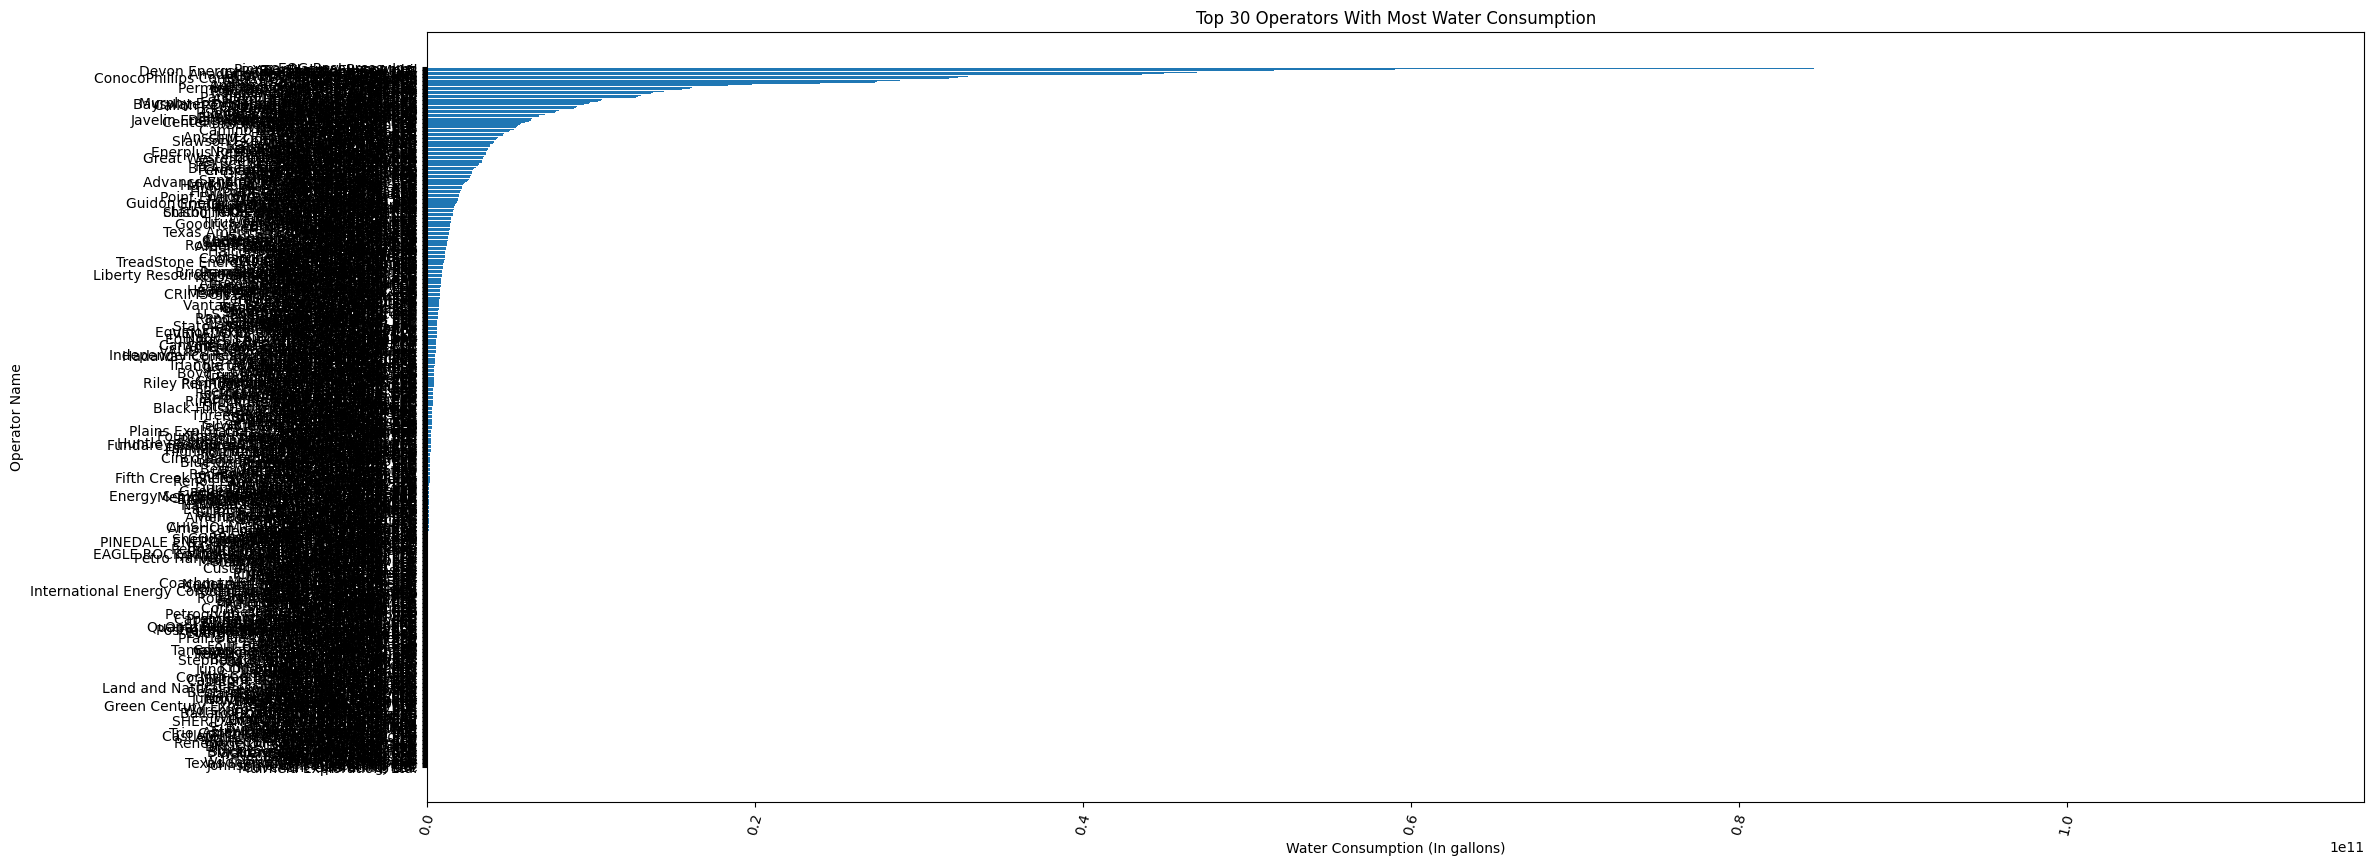

In [294]:
# graph in bar chart
plt.figure(figsize=(25,10))

plt.barh(water_consump_by_operator_df['OperatorName'], water_consump_by_operator_df['total_water_consump'])

plt.xticks(rotation=75)
plt.xlabel('Water Consumption (In gallons)')
plt.ylabel('Operator Name')
plt.title('Top 30 Operators With Most Water Consumption')

plt.gca().invert_yaxis()

plt.show()

In [295]:
# Top 30 Operators by # Disclosures
statement = '''
    SELECT OperatorName, COUNT(*) AS num_disclosures
    FROM disclosures
    GROUP BY OperatorName
    ORDER BY num_disclosures DESC
    LIMIT 30;
'''
top_operators_df = pd.read_sql_query(statement, connection)

# Operators by # Disclosures
statement = '''
    SELECT OperatorName, COUNT(*) AS num_disclosures
    FROM disclosures
    GROUP BY OperatorName
    ORDER BY num_disclosures DESC;
'''
operators_by_disclosures_df = pd.read_sql_query(statement, connection)

top_operators_df

,OperatorName,num_disclosures
0,"EOG Resources, Inc.",10736
1,XTO Energy/ExxonMobil,9082
2,Anadarko Petroleum Corporation,9047
3,"Chesapeake Operating, Inc.",8385
4,Pioneer Natural Resources,7343
5,Devon Energy Production Company L. P.,6716
6,Occidental Oil and Gas,6142
7,Apache Corporation,5252
8,ConocoPhillips Company/Burlington Resources,5011
9,Marathon Oil,4519


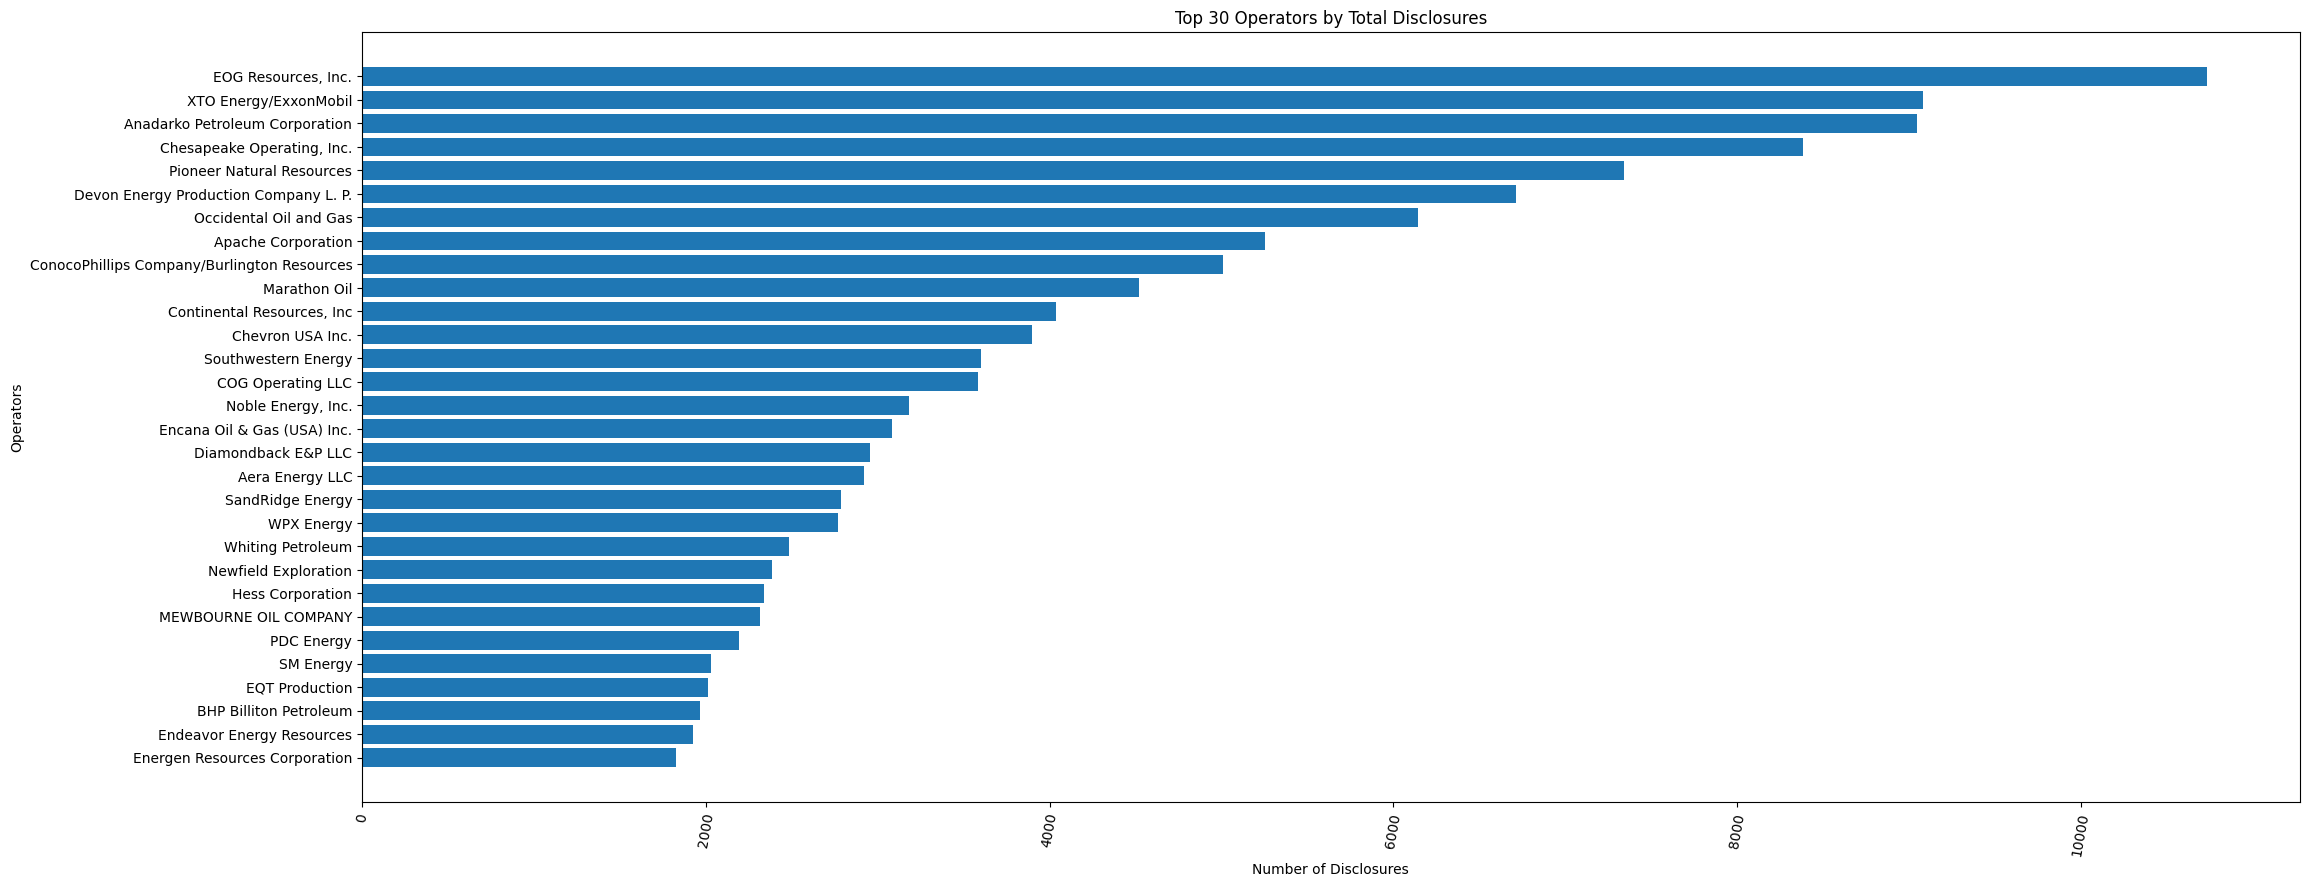

In [296]:
# graph in bar chart
plt.figure(figsize=(25,10))

plt.barh(top_operators_df['OperatorName'], top_operators_df['num_disclosures'])

plt.xticks(rotation=80)
plt.xlabel('Number of Disclosures')
plt.ylabel('Operators')
plt.title('Top 30 Operators by Total Disclosures')

plt.gca().invert_yaxis()

plt.show()

In [297]:
# avg water consumption over time per operator for top 10 operators (with most avg consumption)
#statement = '''
#    SELECT 
#        OperatorName,
#        strftime('%Y-%m', JobStartDate) AS month,
#        AVG(TotalBaseWaterVolume) as avg_water_consum
#    FROM disclosures
#    WHERE OperatorName IN (
#        SELECT OperatorName
#        FROM disclosures
#        WHERE TotalBaseWaterVolume is NOT NULL
#        GROUP BY OperatorName
#        ORDER BY AVG(TotalBaseWaterVolume) DESC
#        LIMIT 10
#    )
#    AND JobStartDate is NOT NULL
#    AND TotalBaseWaterVolume is NOT NULL
#    GROUP BY OperatorName, month
#    ORDER BY OperatorName, month;
#'''

statement = '''
    SELECT 
        OperatorName,
        COUNT(*) as num_disclosures,
        strftime('%Y', JobStartDate) AS year,
        AVG(TotalBaseWaterVolume) as avg_water_consum
    FROM disclosures
    WHERE TotalBaseWaterVolume is NOT NULL
    GROUP BY OperatorName
    ORDER BY OperatorName;
'''

water_consump_over_time_df = pd.read_sql_query(statement, connection)
water_consump_over_time_df

,OperatorName,num_disclosures,year,avg_water_consum
0,1776 Energy Operators,13,2018,9.338635e+06
1,"1849 Energy Partners Operating, LLC",9,2019,1.904339e+06
2,1859 Operating LLC,150,2014,2.707872e+04
3,"1876 Resources, LLC",29,2023,2.072138e+07
4,1920 Energy LLC,2,2025,2.095828e+07
...,...,...,...,...
1979,king energy llc,5,2014,7.214026e+06
1980,lee cox investments,1,2019,5.800200e+04
1981,"red fork production, llc",4,2015,2.187975e+04
1982,"rtb oil,inc.",1,2014,3.379320e+05


In [298]:
# graph in line chart
plt.figure(figsize=(25,10))

# converting month to datetime
water_consump_over_time_df['month'] = pd.to_datetime(water_consump_over_time_df['month'])
# so line moves chronologically
water_consump_over_time_df = water_consump_over_time_df.sort_values(['OperatorName', 'month'])

for operator, group in water_consump_over_time_df.groupby('OperatorName'):
    group = group.sort_values("month")
    plt.plot(group['month'], group['avg_water_consum'], label=operator)

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Average Water Consumption')
plt.title('Average Water Consumption Over Time By Top 10 Operators')

plt.legend()

plt.show()

KeyError: 'month'

<Figure size 2500x1000 with 0 Axes>

In [299]:
# total jobs each year
statement = '''
    SELECT 
        strftime('%Y', JobStartDate) AS year,
        COUNT(8) as num_jobs
    FROM disclosures
    WHERE year IS NOT NULL
    GROUP BY year
    ORDER BY year
'''
jobs_per_year_df = pd.read_sql_query(statement, connection)
jobs_per_year_df

,year,num_jobs
0,1955,1
1,1982,1
2,1995,1
3,1996,1
4,2001,2
5,2002,4
6,2004,2
7,2005,1
8,2007,3
9,2008,6


## Export Visualization Df's

In [ ]:
disclosures_by_state_df.to_csv('disclosures_by_state.csv', index=False)
common_chemicals_df.to_csv('common_chemicals_df.csv', index=False)
water_consump_by_operator_df.to_csv('water_consump_by_operator_df.csv', index=False)
top_operators_df.to_csv('top_operators_df.csv', index=False)
water_consump_over_time_df.to_csv('water_consump_over_time_df.csv', index=False)
operators_by_disclosures_df.to_csv('operators_by_disclosures_df.csv', index=False)
jobs_per_year_df.to_csv('jobs_per_year_df.csv', index=False)